## 0. Improt bibliotek

In [44]:
from pathlib import Path

import duckdb
import folium
import matplotlib.pyplot as plt
import pandas as pd


## 1. ścieżki projektu

In [45]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_PATH = PROJECT_DIR / "data" / "processed" / "environmental_snapshot.csv"
DATABASE_PATH = PROJECT_DIR / "data" / "database" / "environmental_data.duckdb"

print("Folder projektu:", PROJECT_DIR)
print("Plik danych:", DATA_PATH)
print("Baza danych:", DATABASE_PATH)

Folder projektu: c:\Users\sakla\OneDrive\Pulpit\PROJECTS\Internet_data_extraction
Plik danych: c:\Users\sakla\OneDrive\Pulpit\PROJECTS\Internet_data_extraction\data\processed\environmental_snapshot.csv
Baza danych: c:\Users\sakla\OneDrive\Pulpit\PROJECTS\Internet_data_extraction\data\database\environmental_data.duckdb


## 2. wczytanie danych

In [46]:
df = pd.read_csv(DATA_PATH)

print("Liczba wierszy:", df.shape[0])
print("Liczba kolumn:", df.shape[1])

df.head()

Liczba wierszy: 1651
Liczba kolumn: 37


,esa_station_id,school_name,esa_city,esa_street,esa_post_code,esa_latitude,esa_longitude,esa_measured_at,esa_downloaded_at,pm10,...,imgw_latitude,imgw_longitude,distance_to_imgw_km,weather_measured_at,imgw_temperature,imgw_wind_speed,imgw_wind_direction,imgw_relative_humidity,imgw_precipitation,imgw_pressure
0,ESA_c2809d0e7bea,SZKOŁA PODSTAWOWA IM. MARII SKŁODOWSKIEJ-CURIE...,ALWERNIA,UL. MARII SKŁODOWSKIEJ-CURIE,32-566,50.065052,19.542471,2026-06-30 19:08:45,2026-06-30 19:13:27.159927,12.050000,...,50.046943,19.997153,32.523,2026-06-30 17:00:00,30.2,2.0,80.0,55.7,0.00,1016.8
1,ESA_92929c16086b,SZKOŁA PODSTAWOWA IM. ŚW. STANISŁAWA KOSTKI W ...,AMELIN,NaN,06-212,52.981664,20.928181,2026-06-30 19:08:45,2026-06-30 19:13:27.159927,3.233333,...,53.111618,20.383173,39.193,2026-06-30 17:00:00,26.6,3.0,20.0,55.1,7.90,1019.9
2,ESA_f8e5b333e390,SZKOŁA PODSTAWOWA NR 2 IMIENIA MARII KONOPNICK...,ANDRYCHÓW,UL. IGNACEGO DASZYŃSKIEGO,34-120,49.849476,19.344752,2026-06-30 19:08:45,2026-06-30 19:13:27.159927,13.275000,...,49.822118,19.044894,21.719,2026-06-30 17:00:00,28.2,3.0,60.0,60.1,0.01,1016.6
3,ESA_768302abdb7a,TECHNIKUM NR 2 W ZESPOLE SZKÓŁ NR 2 IM.ŚW.JADW...,ANDRYCHÓW,UL. STEFANA BATOREGO,34-120,49.854893,19.341284,2026-06-30 19:08:45,2026-06-30 19:13:27.159927,11.808333,...,49.822118,19.044894,21.566,2026-06-30 17:00:00,28.2,3.0,60.0,60.1,0.01,1016.6
4,ESA_0d6712b91b84,SZKOŁA PODSTAWOWA IM. 18 DYWIZJI PIECHOTY ZIEM...,ANDRZEJEWO,UL. WARSZAWSKA,07-305,52.827925,22.193990,2026-06-30 19:08:45,2026-06-30 19:13:27.159927,1.866667,...,53.077964,21.574843,49.934,2026-06-30 16:00:00,28.3,3.0,340.0,44.2,0.20,1019.8


## 3. kolumny i typy danych

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   esa_station_id                    1651 non-null   str    
 1   school_name                       1651 non-null   str    
 2   esa_city                          1651 non-null   str    
 3   esa_street                        1257 non-null   str    
 4   esa_post_code                     1651 non-null   str    
 5   esa_latitude                      1651 non-null   float64
 6   esa_longitude                     1651 non-null   float64
 7   esa_measured_at                   1651 non-null   str    
 8   esa_downloaded_at                 1651 non-null   str    
 9   pm10                              1651 non-null   float64
 10  pm25                              1651 non-null   float64
 11  esa_temperature                   1649 non-null   float64
 12  esa_humidity     

## 4. szybki podgląd najważniejszych kolumn

In [48]:
selected_columns = [
    "school_name",
    "esa_city",
    "pm10",
    "pm25",
    "esa_temperature",
    "esa_humidity",
    "nearest_gios_station_name",
    "distance_to_gios_km",
    "nearest_imgw_station_name",
    "distance_to_imgw_km",
    "imgw_temperature",
    "imgw_relative_humidity",
    "imgw_pressure",
]

df[selected_columns].head(10)

,school_name,esa_city,pm10,pm25,esa_temperature,esa_humidity,nearest_gios_station_name,distance_to_gios_km,nearest_imgw_station_name,distance_to_imgw_km,imgw_temperature,imgw_relative_humidity,imgw_pressure
0,SZKOŁA PODSTAWOWA IM. MARII SKŁODOWSKIEJ-CURIE...,ALWERNIA,12.050000,10.408333,31.425000,52.783333,"Trzebinia, Os. Związku Walki Młodych",11.470,Kraków,32.523,30.2,55.7,1016.8
1,SZKOŁA PODSTAWOWA IM. ŚW. STANISŁAWA KOSTKI W ...,AMELIN,3.233333,2.825000,30.075000,45.041667,"Ciechanów, ul. Kraszewskiego",24.303,Mława,39.193,26.6,55.1,1019.9
2,SZKOŁA PODSTAWOWA NR 2 IMIENIA MARII KONOPNICK...,ANDRYCHÓW,13.275000,11.525000,30.441667,56.658333,"Żywiec, ul. Kopernika",21.307,Bielsko Biała,21.719,28.2,60.1,1016.6
3,TECHNIKUM NR 2 W ZESPOLE SZKÓŁ NR 2 IM.ŚW.JADW...,ANDRYCHÓW,11.808333,9.683333,30.633333,69.291667,"Oświęcim, ul. J. Bema",20.971,Bielsko Biała,21.566,28.2,60.1,1016.6
4,SZKOŁA PODSTAWOWA IM. 18 DYWIZJI PIECHOTY ZIEM...,ANDRZEJEWO,1.866667,1.866667,30.966667,41.916667,"Wysokie Mazowieckie, ul. 1 Maja",23.220,Ostrołęka,49.934,28.3,44.2,1019.8
5,SZKOŁA PODSTAWOWA W BABKACH OLECKICH,BABKI OLECKIE,1.963636,1.590909,26.781818,54.945455,"Gołdap, ul. Jaćwieska",27.586,Suwałki,27.981,24.8,50.2,1020.5
6,SZKOŁA PODSTAWOWA IM. PPŁK. MAKSYMILIANA CIĘŻK...,BABOROWO,139.576923,139.576923,29.778846,57.540769,"Poznań, ul. Szymanowskiego",23.032,Poznań,28.281,27.7,48.0,1018.7
7,SZKOŁA PODSTAWOWA W BACZYNIE,BACZYN,11.958333,10.683333,31.441667,55.383333,"Sucha Beskidzka, ul. Nieszczyńskiej",9.949,Kraków,34.849,30.2,55.7,1016.8
8,SZKOŁA PODSTAWOWA W BALICACH,BALICE,15.183333,12.991667,32.633333,51.325000,"Zabierzów, ul. Wapienna",3.371,Kraków,15.145,30.2,55.7,1016.8
9,SZKOŁA PODSTAWOWA IM. MIKOŁAJA KOPERNIKA W BAL...,BALIN,18.088889,17.322222,30.444444,65.400000,"Trzebinia, Os. Związku Walki Młodych",7.505,Katowice,26.609,29.6,56.0,1016.8


## 5. podstawowe statystyki

In [49]:
numeric_columns = [
    "pm10",
    "pm25",
    "esa_temperature",
    "esa_humidity",
    "esa_pressure",
    "distance_to_gios_km",
    "distance_to_imgw_km",
    "imgw_temperature",
    "imgw_relative_humidity",
    "imgw_precipitation",
    "imgw_pressure",
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

df[numeric_columns].describe().round(2)

,pm10,pm25,esa_temperature,esa_humidity,esa_pressure,distance_to_gios_km,distance_to_imgw_km,imgw_temperature,imgw_relative_humidity,imgw_precipitation,imgw_pressure
count,1651.00,1651.00,1649.00,1649.00,1649.00,1651.00,1651.00,1651.00,1651.00,1651.00,1613.00
mean,10.25,8.19,32.19,48.15,995.61,11.63,24.20,28.43,52.06,2.29,1018.00
std,8.47,6.94,4.08,12.11,14.82,10.11,14.31,2.99,11.33,3.75,1.48
min,0.00,0.00,-40.00,1.00,936.90,0.04,0.02,15.70,32.80,0.00,1016.20
25%,4.30,3.64,30.70,40.87,986.03,3.07,12.91,27.70,45.80,0.00,1016.80
50%,9.23,7.64,32.47,46.57,996.03,9.13,23.66,29.60,49.70,0.20,1017.70
75%,12.88,10.30,34.34,53.12,1006.48,17.67,34.53,30.20,56.00,3.40,1018.70
max,139.58,139.58,44.80,100.00,1100.00,59.15,67.71,32.00,98.70,11.40,1022.70


## 6. braki danych

In [50]:
missing = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)

missing = missing[missing["missing_count"] > 0].sort_values(
    "missing_count",
    ascending=False,
)

missing

,column,missing_count,missing_percent
17,gios_city,1651,100.00
3,esa_street,394,23.86
36,imgw_pressure,38,2.30
11,esa_temperature,2,0.12
13,esa_pressure,2,0.12
12,esa_humidity,2,0.12


## 7. usunięcie braków danych

In [51]:
df_analysis = df.copy()

# Kolumna gios_city ma 100% braków, więc nie używamy jej dalej.
if "gios_city" in df_analysis.columns:
    df_analysis = df_analysis.drop(columns=["gios_city"])

# Braki w adresie szkoły nie są problemem analitycznym.
if "esa_street" in df_analysis.columns:
    df_analysis["esa_street"] = df_analysis["esa_street"].fillna("brak danych")

print("Liczba rekordów po przygotowaniu:", len(df_analysis))
print("Liczba kolumn po przygotowaniu:", df_analysis.shape[1])

Liczba rekordów po przygotowaniu: 1651
Liczba kolumn po przygotowaniu: 36


## 8. rozkład PM10

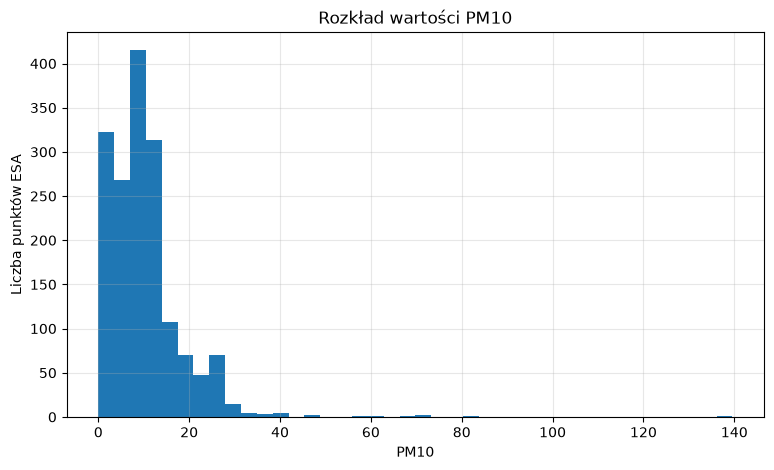

In [52]:
plt.figure(figsize=(9, 5))
plt.hist(df_analysis["pm10"].dropna(), bins=40)
plt.title("Rozkład wartości PM10")
plt.xlabel("PM10")
plt.ylabel("Liczba punktów ESA")
plt.grid(True, alpha=0.3)
plt.show()

## 9.rozkład PM2.5

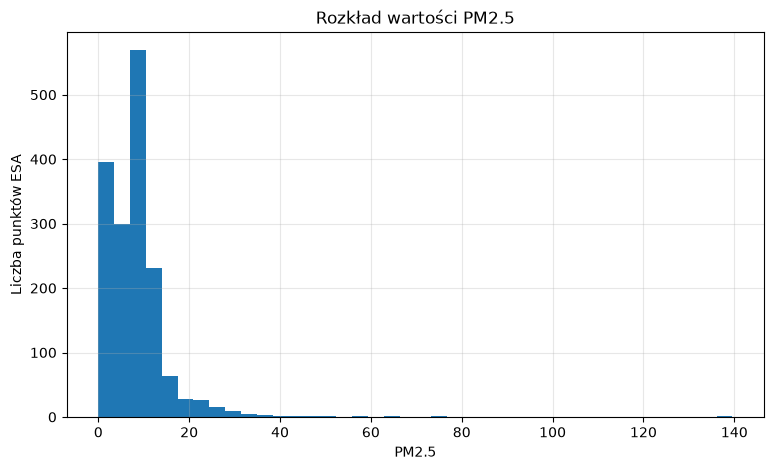

In [53]:
plt.figure(figsize=(9, 5))
plt.hist(df_analysis["pm25"].dropna(), bins=40)
plt.title("Rozkład wartości PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Liczba punktów ESA")
plt.grid(True, alpha=0.3)
plt.show()

## 10. zależność PM10 i PM2.5

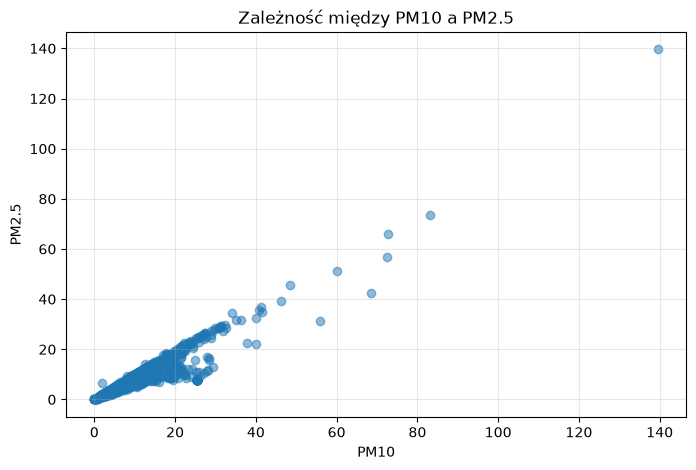

Korelacja PM10 - PM2.5: 0.906


In [54]:
plot_df = df_analysis.dropna(subset=["pm10", "pm25"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["pm10"], plot_df["pm25"], alpha=0.5)
plt.title("Zależność między PM10 a PM2.5")
plt.xlabel("PM10")
plt.ylabel("PM2.5")
plt.grid(True, alpha=0.3)
plt.show()

correlation = plot_df["pm10"].corr(plot_df["pm25"])
print(f"Korelacja PM10 - PM2.5: {correlation:.3f}")

## 11. zależność temperatury IMGW i PM10

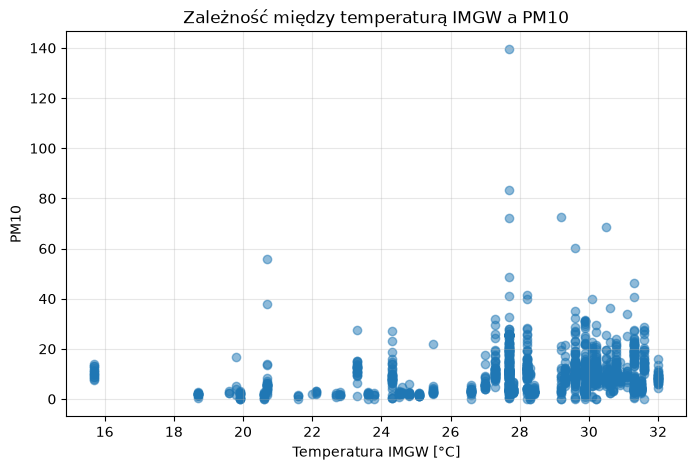

Korelacja temperatura IMGW - PM10: 0.158


In [55]:
plot_df = df_analysis.dropna(subset=["imgw_temperature", "pm10"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["imgw_temperature"], plot_df["pm10"], alpha=0.5)
plt.title("Zależność między temperaturą IMGW a PM10")
plt.xlabel("Temperatura IMGW [°C]")
plt.ylabel("PM10")
plt.grid(True, alpha=0.3)
plt.show()

correlation = plot_df["imgw_temperature"].corr(plot_df["pm10"])
print(f"Korelacja temperatura IMGW - PM10: {correlation:.3f}")

## 12. zależność temperatury IMGW i PM2.5

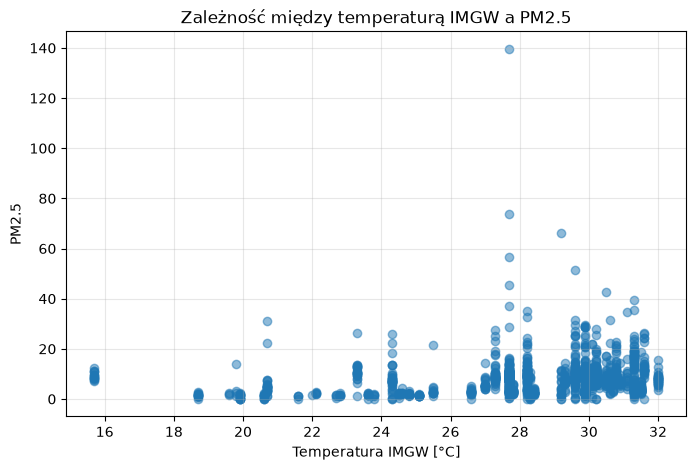

Korelacja temperatura IMGW - PM2.5: 0.197


In [56]:
plot_df = df_analysis.dropna(subset=["imgw_temperature", "pm25"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["imgw_temperature"], plot_df["pm25"], alpha=0.5)
plt.title("Zależność między temperaturą IMGW a PM2.5")
plt.xlabel("Temperatura IMGW [°C]")
plt.ylabel("PM2.5")
plt.grid(True, alpha=0.3)
plt.show()

correlation = plot_df["imgw_temperature"].corr(plot_df["pm25"])
print(f"Korelacja temperatura IMGW - PM2.5: {correlation:.3f}")

## 13. zależność wilgotności IMGW i PM10

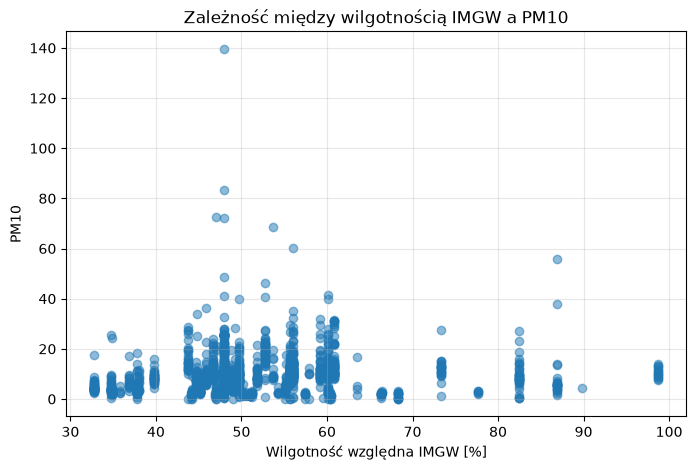

Korelacja wilgotność IMGW - PM10: 0.090


In [57]:
plot_df = df_analysis.dropna(subset=["imgw_relative_humidity", "pm10"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["imgw_relative_humidity"], plot_df["pm10"], alpha=0.5)
plt.title("Zależność między wilgotnością IMGW a PM10")
plt.xlabel("Wilgotność względna IMGW [%]")
plt.ylabel("PM10")
plt.grid(True, alpha=0.3)
plt.show()

correlation = plot_df["imgw_relative_humidity"].corr(plot_df["pm10"])
print(f"Korelacja wilgotność IMGW - PM10: {correlation:.3f}")

## 14. zależność odległości do GIOŚ i PM10

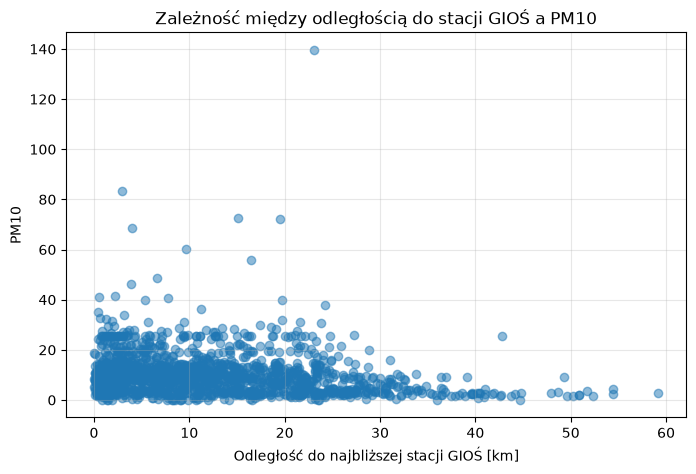

Korelacja odległość do GIOŚ - PM10: -0.175


In [58]:
plot_df = df_analysis.dropna(subset=["distance_to_gios_km", "pm10"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["distance_to_gios_km"], plot_df["pm10"], alpha=0.5)
plt.title("Zależność między odległością do stacji GIOŚ a PM10")
plt.xlabel("Odległość do najbliższej stacji GIOŚ [km]")
plt.ylabel("PM10")
plt.grid(True, alpha=0.3)
plt.show()

correlation = plot_df["distance_to_gios_km"].corr(plot_df["pm10"])
print(f"Korelacja odległość do GIOŚ - PM10: {correlation:.3f}")

## 15. macierz korelacji

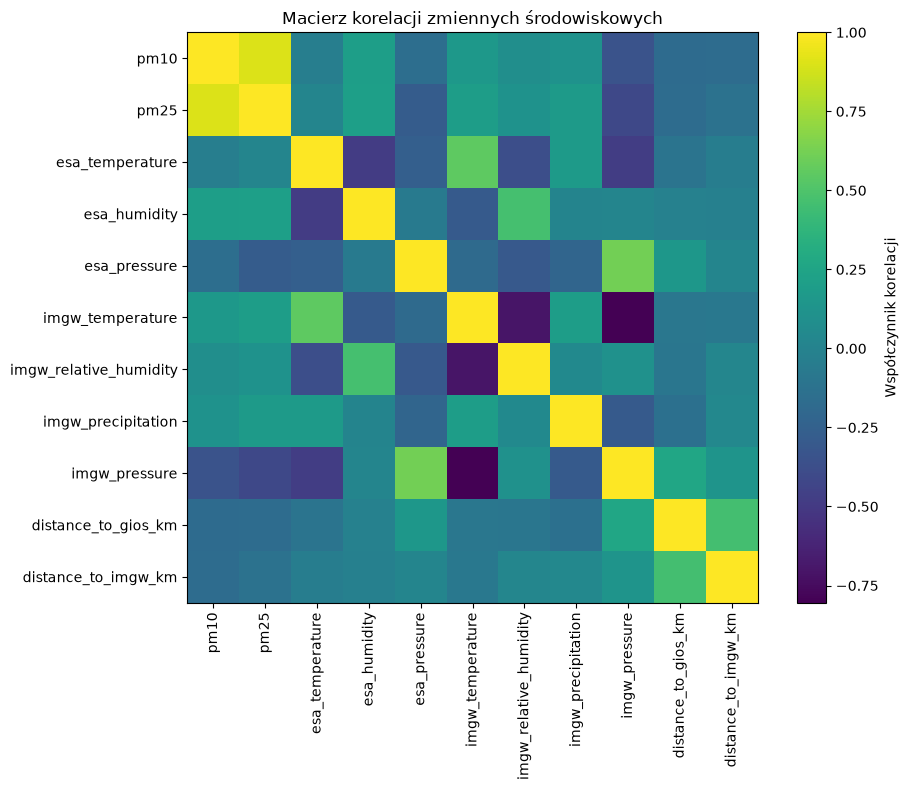

In [59]:
correlation_columns = [
    "pm10",
    "pm25",
    "esa_temperature",
    "esa_humidity",
    "esa_pressure",
    "imgw_temperature",
    "imgw_relative_humidity",
    "imgw_precipitation",
    "imgw_pressure",
    "distance_to_gios_km",
    "distance_to_imgw_km",
]

available_columns = [
    column for column in correlation_columns
    if column in df_analysis.columns
]

correlation_matrix = df_analysis[available_columns].corr(numeric_only=True).round(3)

correlation_matrix

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix)
plt.colorbar(label="Współczynnik korelacji")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
)

plt.title("Macierz korelacji zmiennych środowiskowych")
plt.tight_layout()
plt.show()

## 16. średnie PM10 i PM2.5 według miasta

In [60]:
city_pollution = (
    df_analysis
    .groupby("esa_city")
    .agg(
        liczba_punktow=("esa_station_id", "count"),
        srednie_pm10=("pm10", "mean"),
        srednie_pm25=("pm25", "mean"),
        srednia_temperatura_imgw=("imgw_temperature", "mean"),
        srednia_wilgotnosc_imgw=("imgw_relative_humidity", "mean"),
    )
    .reset_index()
)

# Zostawiamy tylko miasta, które mają co najmniej 2 punkty ESA.
city_pollution = city_pollution[city_pollution["liczba_punktow"] >= 2]

top_cities_pm10 = (
    city_pollution
    .sort_values("srednie_pm10", ascending=False)
    .head(15)
)

top_cities_pm10.round(2)

,esa_city,liczba_punktow,srednie_pm10,srednie_pm25,srednia_temperatura_imgw,srednia_wilgotnosc_imgw
448,KÓRNIK,2,51.80,43.58,27.70,48.00
411,KOŹMIN WIELKOPOLSKI,2,46.11,38.94,29.20,47.00
727,RACIBÓRZ,3,30.56,26.24,31.30,52.80
471,LIBIĄŻ,3,27.90,23.29,29.60,56.00
716,PUSZCZYKOWO,2,25.58,9.26,27.70,48.00
696,PRUDNIK,2,23.82,19.85,31.60,43.70
599,OBORNIKI,3,23.05,8.65,27.70,48.00
992,WODZISŁAW ŚLĄSKI,2,21.96,19.15,31.30,52.80
769,RUDA,2,21.75,21.35,30.85,45.30
708,PRZYSZOWA,2,21.36,20.23,29.90,60.80


## 17. wykres miast z najwyższym średnim PM10

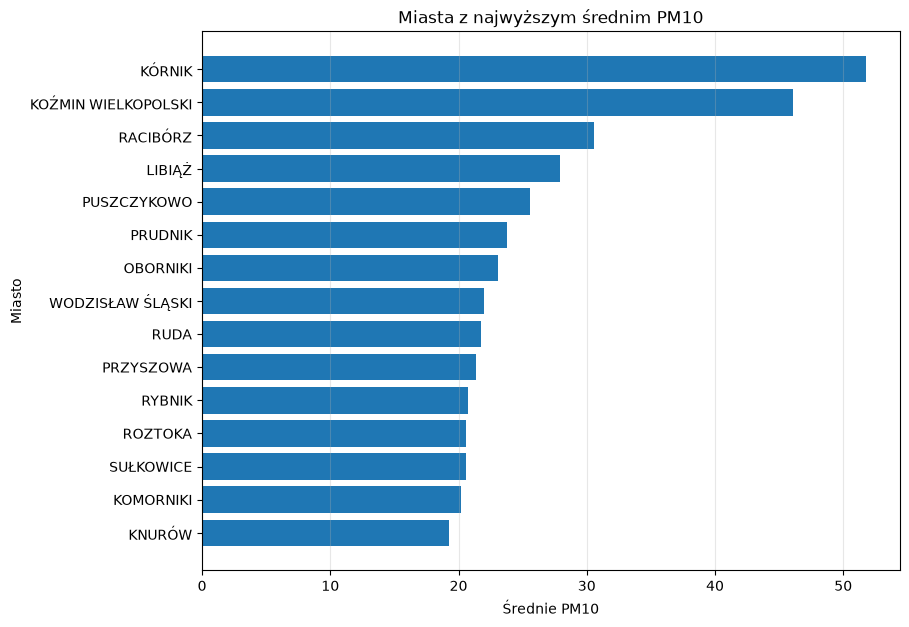

In [61]:
plot_data = top_cities_pm10.sort_values("srednie_pm10", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_data["esa_city"], plot_data["srednie_pm10"])
plt.title("Miasta z najwyższym średnim PM10")
plt.xlabel("Średnie PM10")
plt.ylabel("Miasto")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 18. miasta z najwyższym średnim PM2.5

In [62]:
top_cities_pm25 = (
    city_pollution
    .sort_values("srednie_pm25", ascending=False)
    .head(15)
)

top_cities_pm25.round(2)

,esa_city,liczba_punktow,srednie_pm10,srednie_pm25,srednia_temperatura_imgw,srednia_wilgotnosc_imgw
448,KÓRNIK,2,51.80,43.58,27.70,48.00
411,KOŹMIN WIELKOPOLSKI,2,46.11,38.94,29.20,47.00
727,RACIBÓRZ,3,30.56,26.24,31.30,52.80
471,LIBIĄŻ,3,27.90,23.29,29.60,56.00
769,RUDA,2,21.75,21.35,30.85,45.30
708,PRZYSZOWA,2,21.36,20.23,29.90,60.80
696,PRUDNIK,2,23.82,19.85,31.60,43.70
992,WODZISŁAW ŚLĄSKI,2,21.96,19.15,31.30,52.80
782,RYBNIK,16,20.77,18.70,31.30,52.80
595,NOWY SĄCZ,6,19.14,18.17,29.90,60.80


## 19. wykres miast z najwyższym średnim PM2.5

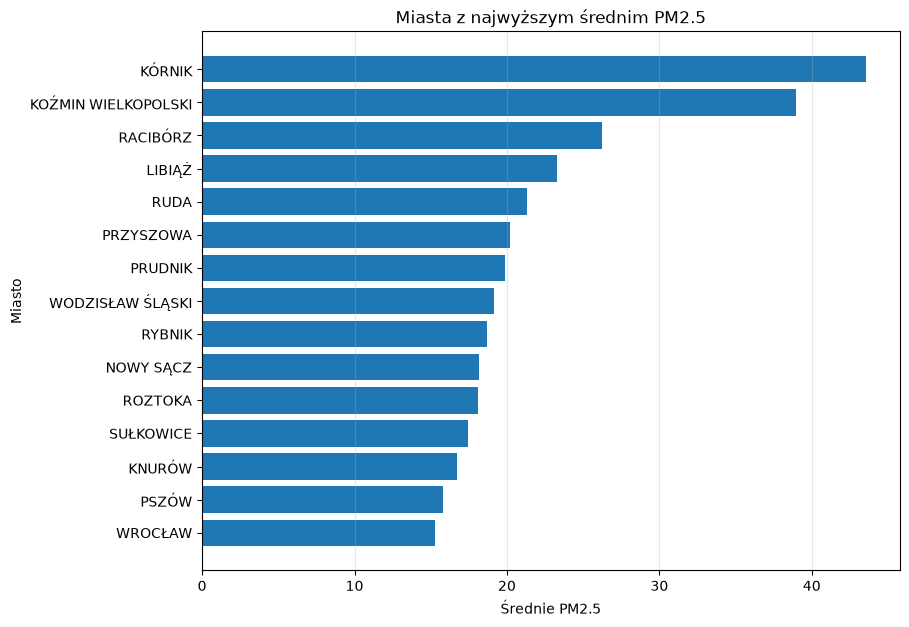

In [63]:
plot_data = top_cities_pm25.sort_values("srednie_pm25", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_data["esa_city"], plot_data["srednie_pm25"])
plt.title("Miasta z najwyższym średnim PM2.5")
plt.xlabel("Średnie PM2.5")
plt.ylabel("Miasto")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 20. najbliższe stacje GIOŚ najczęściej przypisywane do ESA

In [64]:
gios_usage = (
    df_analysis
    .groupby("nearest_gios_station_name")
    .agg(
        liczba_punktow_esa=("esa_station_id", "count"),
        srednia_odleglosc_km=("distance_to_gios_km", "mean"),
        srednie_pm10=("pm10", "mean"),
        srednie_pm25=("pm25", "mean"),
    )
    .reset_index()
    .sort_values("liczba_punktow_esa", ascending=False)
    .head(15)
)

gios_usage.round(2)

,nearest_gios_station_name,liczba_punktow_esa,srednia_odleglosc_km,srednie_pm10,srednie_pm25
152,"Poznań, ul. Szymanowskiego",48,12.14,19.29,12.50
150,"Poznań, ul. Dąbrowskiego",38,7.02,19.48,10.41
121,"Nowy Sącz, ul. Nadbrzeżna",37,13.22,17.56,15.97
148,"Poznan, ul. Hetmańska",26,4.40,13.13,8.01
149,Poznań ul. Szwajcarska,24,6.23,14.88,9.22
10,"Bochnia, ul. Konfederatów Barskich",23,13.82,10.88,9.58
110,"Mosina, ul. Czereśniowa",20,13.00,17.25,9.29
198,"Tarnów, ul. Ks. Romana Sitko",19,8.11,8.57,7.80
133,Osieczów,18,14.29,9.54,6.98
233,"Zabrze, ul. M. Skłodowskiej-Curie",18,3.93,11.27,9.59


## 21. wykres najczęściej przypisywanych stacji GIOŚ

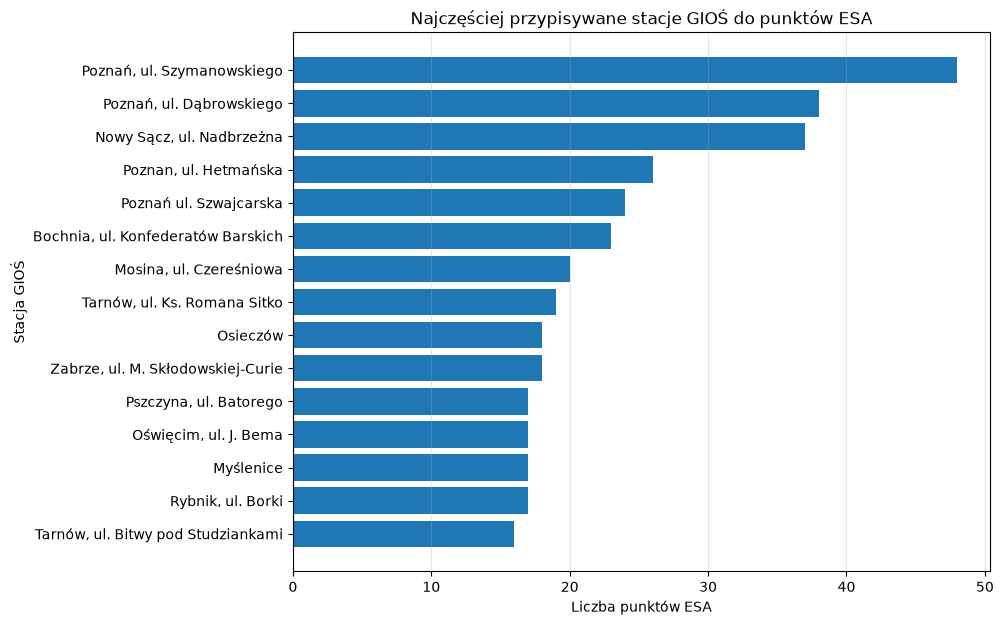

In [65]:
plot_data = gios_usage.sort_values("liczba_punktow_esa", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_data["nearest_gios_station_name"], plot_data["liczba_punktow_esa"])
plt.title("Najczęściej przypisywane stacje GIOŚ do punktów ESA")
plt.xlabel("Liczba punktów ESA")
plt.ylabel("Stacja GIOŚ")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 22. najczęściej przypisywane stacje IMGW

In [66]:
imgw_usage = (
    df_analysis
    .groupby("nearest_imgw_station_name")
    .agg(
        liczba_punktow_esa=("esa_station_id", "count"),
        srednia_odleglosc_km=("distance_to_imgw_km", "mean"),
        srednie_pm10=("pm10", "mean"),
        srednie_pm25=("pm25", "mean"),
        srednia_temperatura=("imgw_temperature", "mean"),
    )
    .reset_index()
    .sort_values("liczba_punktow_esa", ascending=False)
    .head(15)
)

imgw_usage.round(2)

,nearest_imgw_station_name,liczba_punktow_esa,srednia_odleglosc_km,srednie_pm10,srednie_pm25,srednia_temperatura
32,Poznań,211,15.71,16.84,9.95,27.7
16,Kraków,115,22.26,11.40,10.18,30.2
10,Katowice,109,22.07,13.14,11.38,29.6
49,Warszawa,81,27.55,4.13,3.38,29.9
1,Bielsko Biała,79,21.05,13.29,11.06,28.2
51,Wrocław,70,25.03,11.06,8.76,30.1
45,Tarnów,66,17.36,9.60,8.58,30.6
27,Nowy Sącz,64,19.18,15.07,13.59,29.9
3,Częstochowa,51,22.52,12.31,10.64,30.8
19,Kłodzko,47,25.42,12.55,10.39,27.3


## 23. wykres najczęściej przypisywanych stacji IMGW

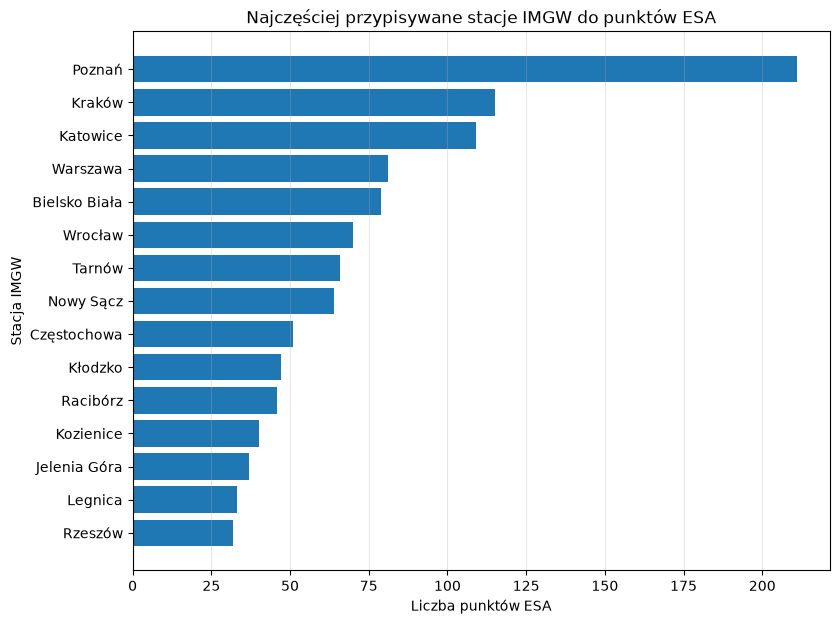

In [67]:
plot_data = imgw_usage.sort_values("liczba_punktow_esa", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_data["nearest_imgw_station_name"], plot_data["liczba_punktow_esa"])
plt.title("Najczęściej przypisywane stacje IMGW do punktów ESA")
plt.xlabel("Liczba punktów ESA")
plt.ylabel("Stacja IMGW")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 24. mapa punktów ESA z najwyższym PM10

In [68]:
map_df = df_analysis.dropna(
    subset=[
        "esa_latitude",
        "esa_longitude",
        "pm10",
        "pm25",
    ]
).copy()

# Żeby mapa działała płynnie, pokazujemy 300 punktów z najwyższym PM10.
map_df = map_df.sort_values("pm10", ascending=False).head(300)

center_lat = map_df["esa_latitude"].mean()
center_lon = map_df["esa_longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
)

for _, row in map_df.iterrows():
    popup_text = f"""
    <b>{row['school_name']}</b><br>
    Miasto: {row['esa_city']}<br>
    PM10: {row['pm10']:.2f}<br>
    PM2.5: {row['pm25']:.2f}<br>
    Najbliższa stacja GIOŚ: {row['nearest_gios_station_name']}<br>
    Odległość do GIOŚ: {row['distance_to_gios_km']:.2f} km<br>
    Najbliższa stacja IMGW: {row['nearest_imgw_station_name']}<br>
    Odległość do IMGW: {row['distance_to_imgw_km']:.2f} km<br>
    Temperatura IMGW: {row['imgw_temperature']} °C<br>
    Wilgotność IMGW: {row['imgw_relative_humidity']} %
    """

    folium.CircleMarker(
        location=[row["esa_latitude"], row["esa_longitude"]],
        radius=4,
        popup=folium.Popup(popup_text, max_width=350),
        tooltip=f"{row['esa_city']} | PM10: {row['pm10']:.2f}",
        fill=True,
    ).add_to(m)

m

## 25. zapis mapy do HTML

In [69]:
OUTPUT_MAP = PROJECT_DIR / "data" / "processed" / "esa_pm10_map.html"

m.save(OUTPUT_MAP)

print("Mapa zapisana do:", OUTPUT_MAP)

Mapa zapisana do: c:\Users\sakla\OneDrive\Pulpit\PROJECTS\Internet_data_extraction\data\processed\esa_pm10_map.html


## 26. wczytanie historii pomiarów ESA z bazy

In [70]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATABASE_PATH = PROJECT_DIR / "data" / "database" / "environmental_data.duckdb"

print("Baza danych:", DATABASE_PATH)

con = duckdb.connect(str(DATABASE_PATH))

query = """
SELECT
    measurement_id,
    station_id AS esa_station_id,
    measured_at,
    downloaded_at,
    pm10,
    pm25,
    temperature,
    humidity,
    pressure
FROM air_measurements
ORDER BY measured_at
"""

df_time = con.execute(query).df()
con.close()

df_time["measured_at"] = pd.to_datetime(df_time["measured_at"], errors="coerce")
df_time["downloaded_at"] = pd.to_datetime(df_time["downloaded_at"], errors="coerce")

df_time["date"] = df_time["measured_at"].dt.date
df_time["hour"] = df_time["measured_at"].dt.hour

print("Liczba rekordów historycznych ESA:", len(df_time))
print("Zakres czasu:", df_time["measured_at"].min(), "->", df_time["measured_at"].max())
print("Liczba dni w danych:", df_time["date"].nunique())

df_time.head()

Baza danych: c:\Users\sakla\OneDrive\Pulpit\PROJECTS\Internet_data_extraction\data\database\environmental_data.duckdb
Liczba rekordów historycznych ESA: 11412
Zakres czasu: 2026-06-30 14:38:15 -> 2026-06-30 19:08:45
Liczba dni w danych: 1


,measurement_id,esa_station_id,measured_at,downloaded_at,pm10,pm25,temperature,humidity,pressure,date,hour
0,MEAS_78925ccb601a,ESA_00594f376537,2026-06-30 14:38:15,2026-06-30 14:40:33.645825,12.108333,9.758333,33.233333,53.733333,989.775000,2026-06-30,14
1,MEAS_136e6eeba6b5,ESA_006a16901939,2026-06-30 14:38:15,2026-06-30 14:40:33.645825,17.811111,15.100000,30.977778,59.577778,990.744444,2026-06-30,14
2,MEAS_49c8f89b4030,ESA_009aae625f36,2026-06-30 14:38:15,2026-06-30 14:40:33.645825,15.307692,6.769231,28.760385,52.817308,1015.725769,2026-06-30,14
3,MEAS_867d4d0b70fc,ESA_00a2f701f97f,2026-06-30 14:38:15,2026-06-30 14:40:33.645825,1.418182,1.100000,25.309091,44.100000,1018.709091,2026-06-30,14
4,MEAS_4be6233390d5,ESA_00bd30e84c99,2026-06-30 14:38:15,2026-06-30 14:40:33.645825,8.383333,7.083333,27.700000,58.683333,1002.716667,2026-06-30,14


## 27. liczba pomiarów w poszczególnych godzinach

In [71]:
hour_counts = (
    df_time
    .dropna(subset=["hour"])
    .groupby("hour")
    .size()
    .reset_index(name="liczba_pomiarow")
    .sort_values("hour")
)

hour_counts

,hour,liczba_pomiarow
0,14,4902
1,15,3262
2,18,1624
3,19,1624


## 28. średnie PM10 i PM2.5 według godziny

In [72]:
hourly_pollution = (
    df_time
    .dropna(subset=["hour", "pm10", "pm25"])
    .groupby("hour")
    .agg(
        srednie_pm10=("pm10", "mean"),
        srednie_pm25=("pm25", "mean"),
        liczba_pomiarow=("measurement_id", "count"),
    )
    .reset_index()
    .sort_values("hour")
)

hourly_pollution.round(2)

,hour,srednie_pm10,srednie_pm25,liczba_pomiarow
0,14,10.22,8.38,4902
1,15,10.11,8.27,3262
2,18,10.20,8.14,1624
3,19,10.20,8.14,1624


## 29. wykres zmian PM10 i PM2.5 w ciągu dnia

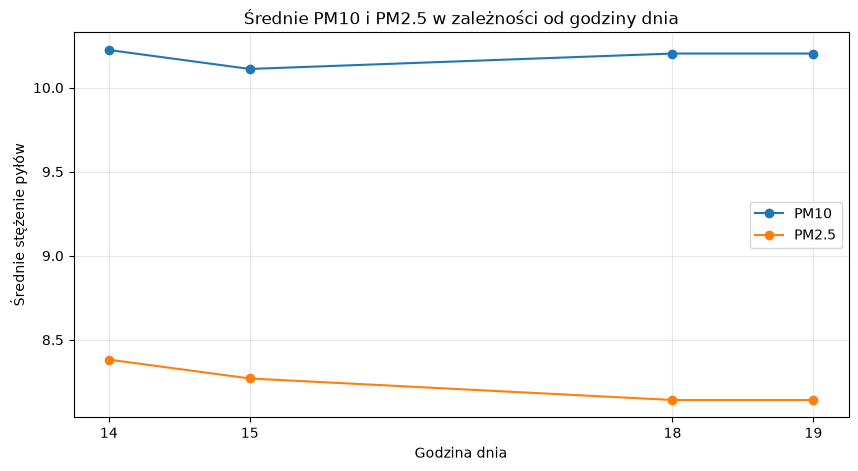

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pollution["hour"],
    hourly_pollution["srednie_pm10"],
    marker="o",
    label="PM10",
)

plt.plot(
    hourly_pollution["hour"],
    hourly_pollution["srednie_pm25"],
    marker="o",
    label="PM2.5",
)

plt.title("Średnie PM10 i PM2.5 w zależności od godziny dnia")
plt.xlabel("Godzina dnia")
plt.ylabel("Średnie stężenie pyłów")
plt.xticks(hourly_pollution["hour"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 30. średnie parametry pogodowe według godziny

In [74]:
hourly_weather = (
    df_time
    .dropna(subset=["hour"])
    .groupby("hour")
    .agg(
        srednia_temperatura=("temperature", "mean"),
        srednia_wilgotnosc=("humidity", "mean"),
        srednie_cisnienie=("pressure", "mean"),
        liczba_pomiarow=("measurement_id", "count"),
    )
    .reset_index()
    .sort_values("hour")
)

hourly_weather.round(2)

,hour,srednia_temperatura,srednia_wilgotnosc,srednie_cisnienie,liczba_pomiarow
0,14,31.40,50.17,998.10,4902
1,15,31.74,49.13,997.96,3262
2,18,32.17,48.17,995.65,1624
3,19,32.17,48.17,995.65,1624


## 31. wykres temperatury, wilgotności i ciśnienia według godziny

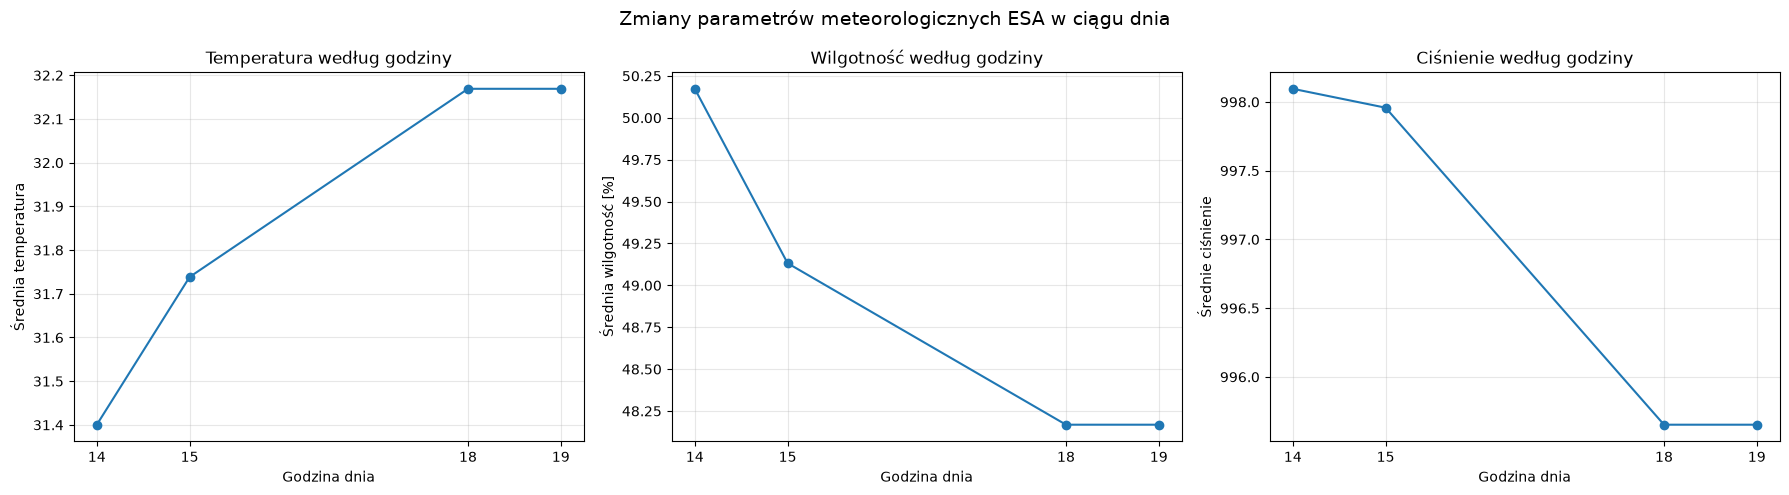

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wykres 1 — temperatura
axes[0].plot(
    hourly_weather["hour"],
    hourly_weather["srednia_temperatura"],
    marker="o",
)

axes[0].set_title("Temperatura według godziny")
axes[0].set_xlabel("Godzina dnia")
axes[0].set_ylabel("Średnia temperatura")
axes[0].set_xticks(hourly_weather["hour"])
axes[0].grid(True, alpha=0.3)


# Wykres 2 — wilgotność
axes[1].plot(
    hourly_weather["hour"],
    hourly_weather["srednia_wilgotnosc"],
    marker="o",
)

axes[1].set_title("Wilgotność według godziny")
axes[1].set_xlabel("Godzina dnia")
axes[1].set_ylabel("Średnia wilgotność [%]")
axes[1].set_xticks(hourly_weather["hour"])
axes[1].grid(True, alpha=0.3)


# Wykres 3 — ciśnienie
axes[2].plot(
    hourly_weather["hour"],
    hourly_weather["srednie_cisnienie"],
    marker="o",
)

axes[2].set_title("Ciśnienie według godziny")
axes[2].set_xlabel("Godzina dnia")
axes[2].set_ylabel("Średnie ciśnienie")
axes[2].set_xticks(hourly_weather["hour"])
axes[2].grid(True, alpha=0.3)


plt.suptitle("Zmiany parametrów meteorologicznych ESA w ciągu dnia", fontsize=14)
plt.tight_layout()
plt.show()

## 32. zależności zanieczyszczeń od czynników atmosferycznych 

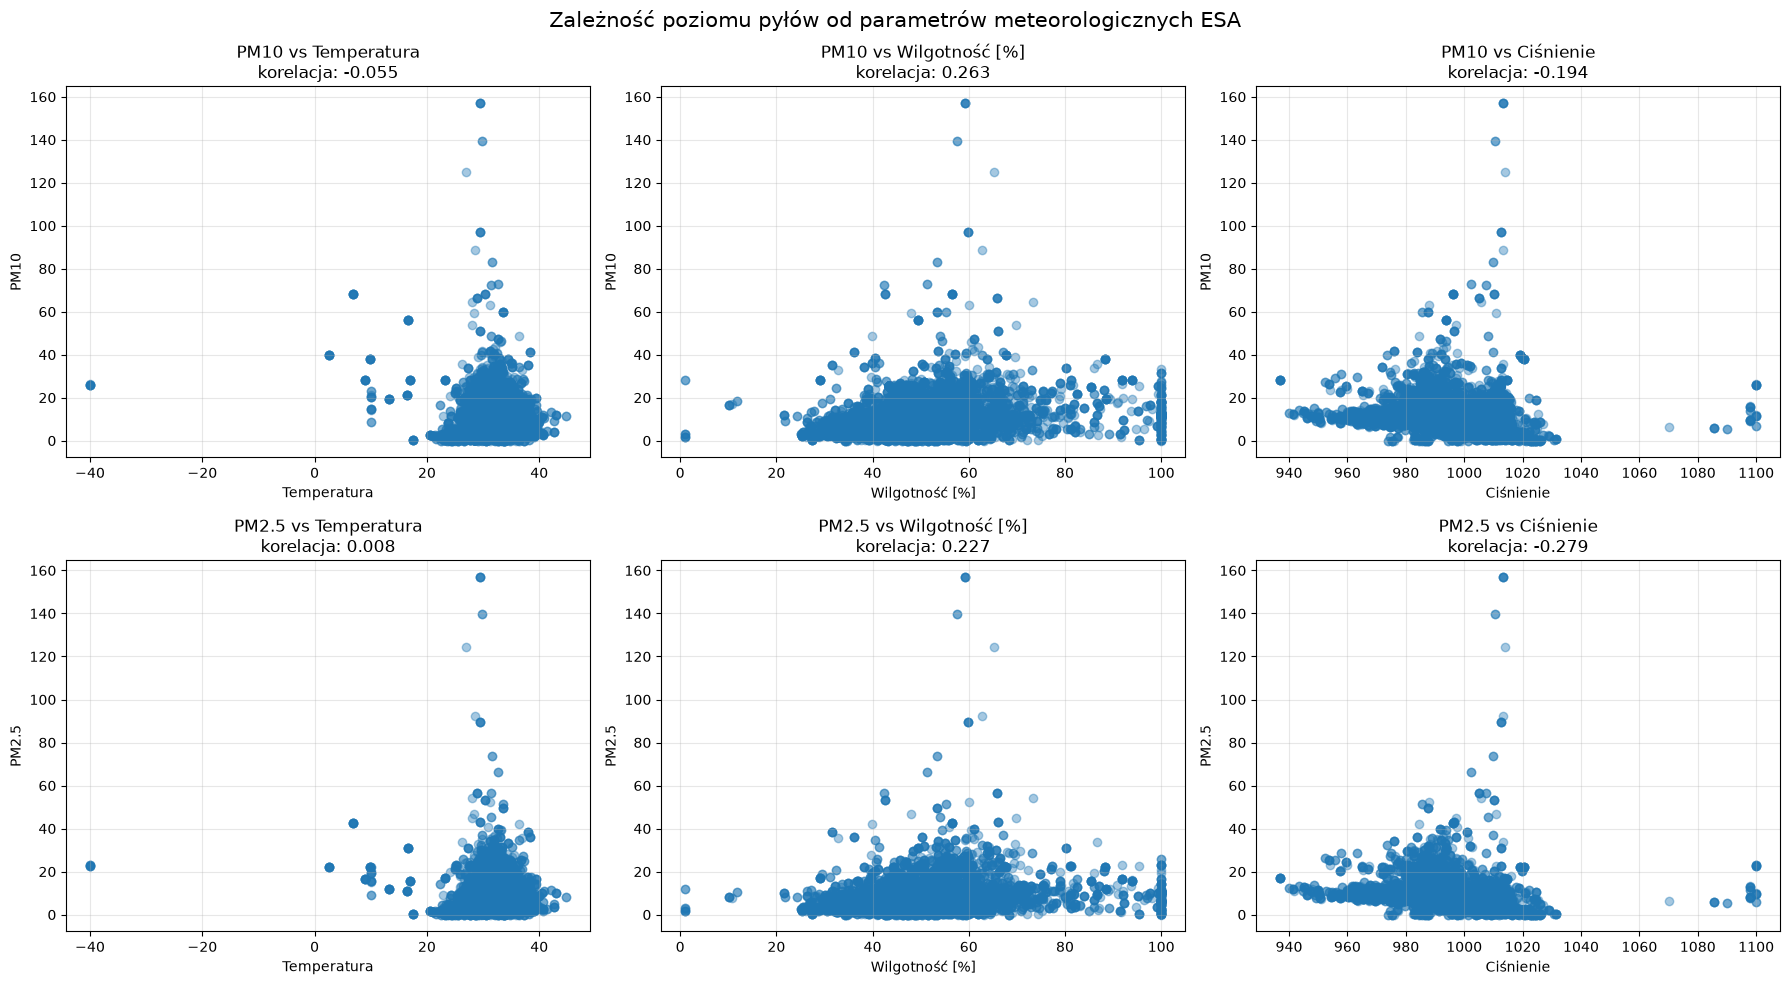

In [76]:
plot_df = df_time.dropna(
    subset=[
        "temperature",
        "humidity",
        "pressure",
        "pm10",
        "pm25",
    ]
).copy()

variables = [
    ("temperature", "Temperatura"),
    ("humidity", "Wilgotność [%]"),
    ("pressure", "Ciśnienie"),
]

pollutants = [
    ("pm10", "PM10"),
    ("pm25", "PM2.5"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_index, (pollutant_column, pollutant_label) in enumerate(pollutants):
    for col_index, (weather_column, weather_label) in enumerate(variables):
        
        ax = axes[row_index, col_index]
        
        ax.scatter(
            plot_df[weather_column],
            plot_df[pollutant_column],
            alpha=0.4,
        )
        
        correlation = plot_df[weather_column].corr(plot_df[pollutant_column])
        
        ax.set_title(
            f"{pollutant_label} vs {weather_label}\n"
            f"korelacja: {correlation:.3f}"
        )
        ax.set_xlabel(weather_label)
        ax.set_ylabel(pollutant_label)
        ax.grid(True, alpha=0.3)

plt.suptitle(
    "Zależność poziomu pyłów od parametrów meteorologicznych ESA",
    fontsize=15,
)

plt.tight_layout()
plt.show()

## 33. korelacja zanieczyszczeń od czynników atmosferycznych 

In [77]:
correlation_results = []

for pollutant_column, pollutant_label in pollutants:
    for weather_column, weather_label in variables:
        correlation = plot_df[weather_column].corr(plot_df[pollutant_column])
        
        correlation_results.append(
            {
                "zanieczyszczenie": pollutant_label,
                "parametr_pogodowy": weather_label,
                "korelacja": round(correlation, 3),
            }
        )

correlation_results_df = pd.DataFrame(correlation_results)

correlation_results_df

,zanieczyszczenie,parametr_pogodowy,korelacja
0,PM10,Temperatura,-0.055
1,PM10,Wilgotność [%],0.263
2,PM10,Ciśnienie,-0.194
3,PM2.5,Temperatura,0.008
4,PM2.5,Wilgotność [%],0.227
5,PM2.5,Ciśnienie,-0.279


## 34. profil czasowy dla jednej stacji ESA

Wybrana stacja ESA: ESA_00594f376537
Liczba rekordów dla stacji: 7


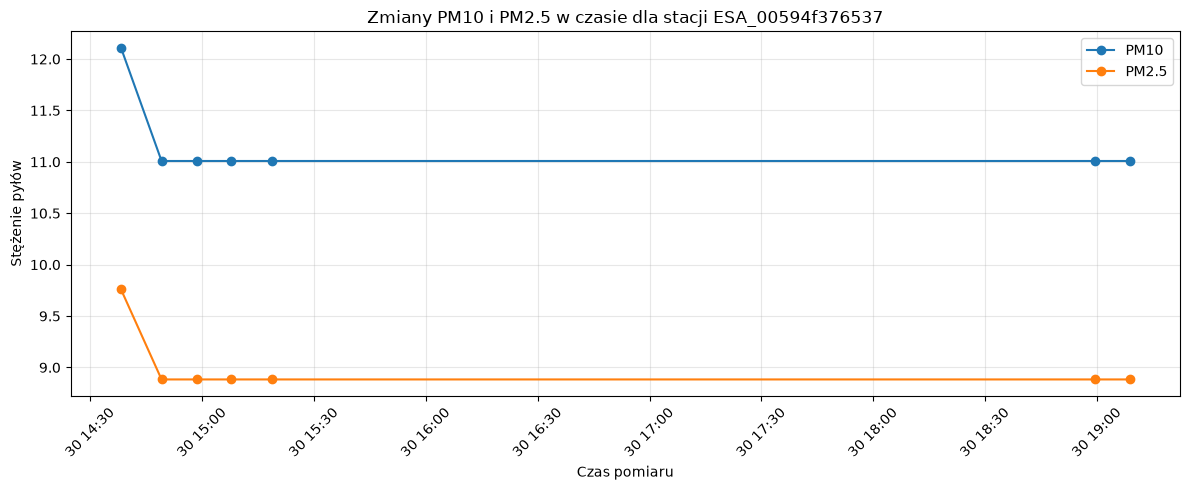

In [78]:
top_station = (
    df_time
    .dropna(subset=["esa_station_id"])
    ["esa_station_id"]
    .value_counts()
    .index[0]
)

station_df = (
    df_time[df_time["esa_station_id"] == top_station]
    .sort_values("measured_at")
    .copy()
)

print("Wybrana stacja ESA:", top_station)
print("Liczba rekordów dla stacji:", len(station_df))

plt.figure(figsize=(12, 5))

plt.plot(
    station_df["measured_at"],
    station_df["pm10"],
    marker="o",
    label="PM10",
)

plt.plot(
    station_df["measured_at"],
    station_df["pm25"],
    marker="o",
    label="PM2.5",
)

plt.title(f"Zmiany PM10 i PM2.5 w czasie dla stacji {top_station}")
plt.xlabel("Czas pomiaru")
plt.ylabel("Stężenie pyłów")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()